In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import squigglepy as sq

from metr import fit_metr, load_metr_data

In [2]:
df = load_metr_data("data/benchmark_results_1_1.yaml", sota_only=True, since=date(2023, 1, 1))
fit = fit_metr(df)

print(
    f"h50 fit: log(h) = {fit.intercept_50:.4f} + {fit.slope_50:.5f} * t  "
    f"(R² = {fit.r_squared_50:.3f})"
)
print(
    f"h80 fit: log(h) = {fit.intercept_80:.4f} + {fit.slope_80:.5f} * t  "
    f"(R² = {fit.r_squared_80:.3f})"
)
print(f"Doubling time: {fit.doubling_time_months:.2f} months")

h50 fit: log(h) = 0.3314 + 0.16389 * t  (R² = 0.934)
h80 fit: log(h) = -1.2533 + 0.15816 * t  (R² = 0.903)
Doubling time: 4.23 months


In [3]:
years = range(fit.base_date.year, 2038)
dates = [date(y, 1, 1) for y in years]
t_months = [(d - fit.base_date).days / 30.44 for d in dates]
n_samples = 500

# h50 ceiling options (set to None for exponential, or a value/distribution for logistic)
# ceiling = None  # exponential (unbounded)
# ceiling = 30 * 24 * 60  # fixed: 1 month
ceiling = sq.lognorm(df["p50_horizon"].max(), 30 * 24 * 60) @ n_samples

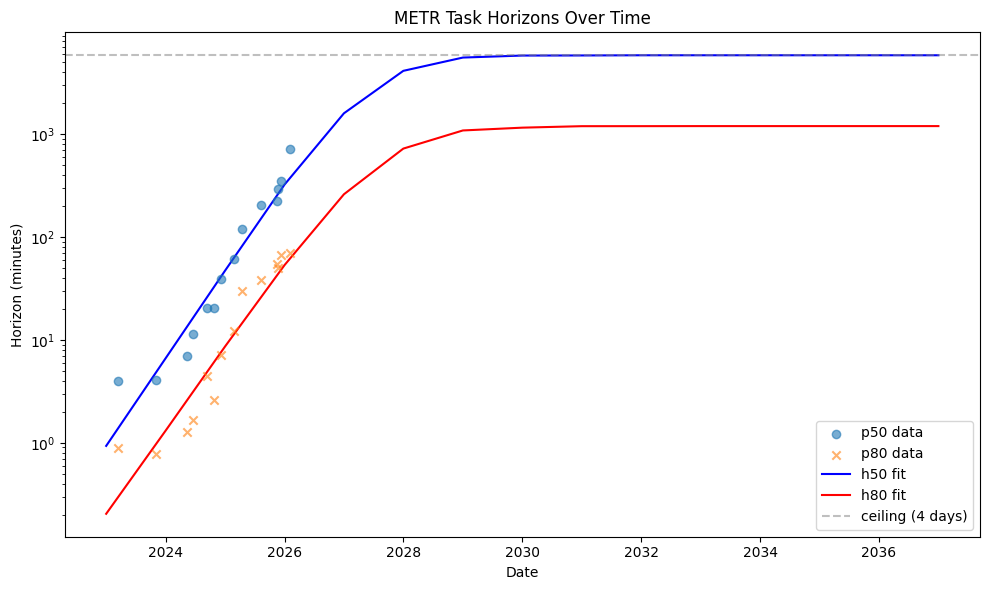

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Data points
ax.scatter(df["release_date"], df["p50_horizon"], alpha=0.6, label="p50 data", zorder=3)
ax.scatter(df["release_date"], df["p80_horizon"], alpha=0.6, label="p80 data", zorder=3, marker="x")

# Sample horizons at each date
h50_samples = np.array([fit.sample_horizons(t, n=n_samples, ceiling=ceiling)[0] for t in t_months])
h80_samples = np.array([fit.sample_horizons(t, n=n_samples, ceiling=ceiling)[1] for t in t_months])

h50_median = np.median(h50_samples, axis=1)
h80_median = np.median(h80_samples, axis=1)

ax.plot(dates, h50_median, "b-", label="h50 fit")
ax.plot(dates, h80_median, "r-", label="h80 fit")

# Show ceiling if set
if ceiling is not None:
    ceil_val = ceiling if isinstance(ceiling, (int, float)) else np.median(ceiling)
    ax.axhline(
        y=ceil_val,
        color="gray",
        linestyle="--",
        alpha=0.5,
        label=f"ceiling ({ceil_val / 60 / 24:.0f} days)",
    )

ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Horizon (minutes)")
ax.set_title("METR Task Horizons Over Time")
ax.legend()
plt.tight_layout()
plt.show()

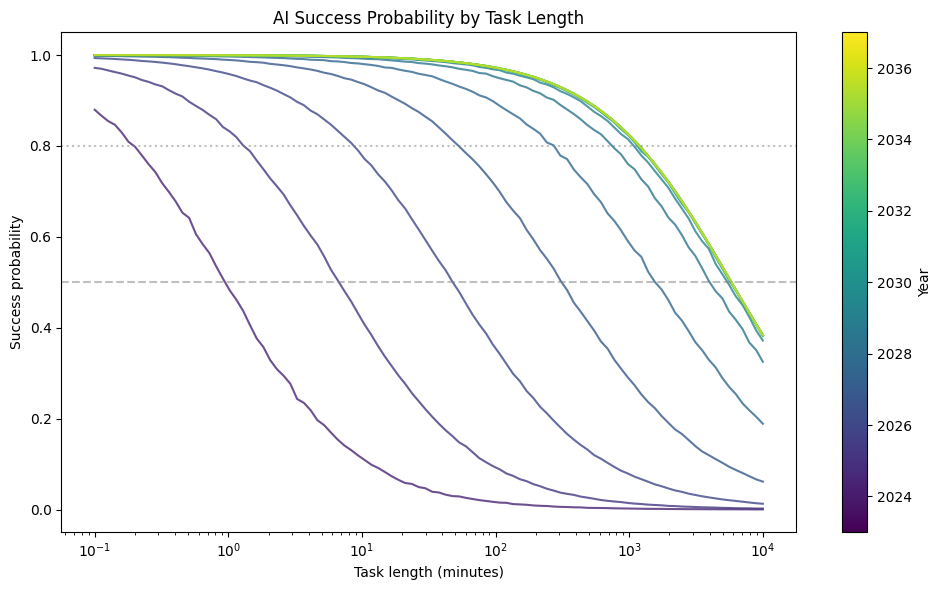

In [5]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 6))

task_range_min = np.logspace(-1, 4, 100)  # 0.1 min to 10,000 min

# Color gradient from light to dark
colors = cm.viridis(np.linspace(0.1, 0.9, len(years)))

for i, year in enumerate(years):
    d = date(year, 1, 1)
    t = (d - fit.base_date).days / 30.44

    # Median success probability at each task length
    probs = np.array(
        [
            np.median(fit.success_probability(task, t, n=n_samples, ceiling=ceiling))
            for task in task_range_min
        ]
    )
    ax.plot(task_range_min, probs, color=colors[i], alpha=0.8)

ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="50%")
ax.axhline(y=0.8, color="gray", linestyle=":", alpha=0.5, label="80%")
ax.set_xscale("log")
ax.set_xlabel("Task length (minutes)")
ax.set_ylabel("Success probability")
ax.set_title("AI Success Probability by Task Length")

# Add colorbar for years
sm = cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(min(years), max(years)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Year")

plt.tight_layout()
plt.show()

In [6]:
sw_task_distribution = sq.lognorm(10, 480)  # 90% CI: 10 min to 8 hr

n_tasks = 100000
task_durations = sw_task_distribution @ n_tasks
total_volume = np.sum(task_durations)

rows = []
for d, t in zip(dates, t_months):
    # Sample horizons once per date
    h50, h80 = fit.sample_horizons(t, n=n_samples, ceiling=ceiling)
    k = np.log(0.25) / np.log(h80 / h50)

    for i in range(n_samples):
        # Compute expected automated volume using success probability curve
        # Numerically stable calculation
        log_ratio = k[i] * np.log(task_durations / h50[i])
        log_ratio = np.clip(log_ratio, -50, 50)
        probs = 1 / (1 + np.exp(log_ratio))
        automated_volume = np.sum(task_durations * probs)
        frac_automated = automated_volume / total_volume
        speedup = 1 / (1 - frac_automated)

        rows.append(
            {
                "date": d,
                "h50": h50[i],
                "h80": h80[i],
                "k": k[i],
                "frac_automated": frac_automated,
                "speedup": speedup,
            }
        )

results = pd.DataFrame(rows)

# Summarize by year
summary = (
    results.groupby("date")
    .agg(
        h50_median=("h50", "median"),
        h80_median=("h80", "median"),
        k_median=("k", "median"),
        frac_automated_median=("frac_automated", "median"),
        speedup_median=("speedup", "median"),
        speedup_p5=("speedup", lambda x: np.percentile(x, 5)),
        speedup_p95=("speedup", lambda x: np.percentile(x, 95)),
    )
    .reset_index()
)

print(summary.to_string(index=False))

      date  h50_median  h80_median  k_median  frac_automated_median  speedup_median  speedup_p5  speedup_p95
2023-01-01    0.957258    0.192616  0.880723               0.010971        1.011093    1.004043     1.023835
2024-01-01    6.775651    1.297698  0.840198               0.061833        1.065908    1.046751     1.090531
2025-01-01   47.612336    8.672336  0.809165               0.229931        1.298585    1.256027     1.349189
2026-01-01  319.920730   54.771295  0.788574               0.525041        2.105445    1.868624     2.373683
2027-01-01 1593.051514  263.796515  0.791706               0.760733        4.179428    2.668247     6.141189
2028-01-01 4096.728561  758.157227  0.836530               0.869385        7.656101    2.979222    16.687097
2029-01-01 5463.367461 1075.091511  0.867355               0.898074        9.810997    3.030866    31.133274
2030-01-01 5730.510827 1161.918443  0.873191               0.904937       10.519407    3.038644    46.427403
2031-01-01 5803.945

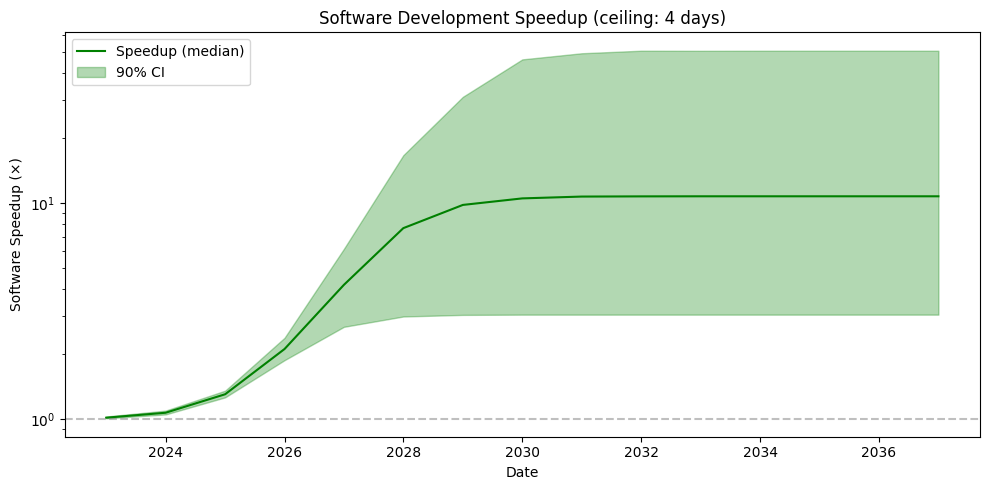

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(summary["date"], summary["speedup_median"], "g-", label="Speedup (median)")
ax.fill_between(
    summary["date"],
    summary["speedup_p5"],
    summary["speedup_p95"],
    alpha=0.3,
    color="green",
    label="90% CI",
)
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Software Speedup (×)")

title = "Software Development Speedup"
if ceiling is not None:
    ceil_val = ceiling if isinstance(ceiling, (int, float)) else np.median(ceiling)
    title += f" (ceiling: {ceil_val / 60 / 24:.0f} days)"
ax.set_title(title)

ax.legend(loc="upper left")
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [8]:
from physical import (
    HardwareCapability,
    PhysicalHorizon,
    sample_physical_speedup,
)

ph = PhysicalHorizon()
hw = HardwareCapability()

# Use median software speedup from METR model at each time point
sw_speedup_by_year = dict(zip(summary["date"], summary["speedup_median"]))

# Physical task duration distributions (literature-anchored)
phys_tasks_structured = sq.lognorm(5, 240) @ n_tasks  # 5 min to 4 hr
phys_tasks_unstructured = sq.lognorm(5, 480) @ n_tasks  # 5 min to 8 hr

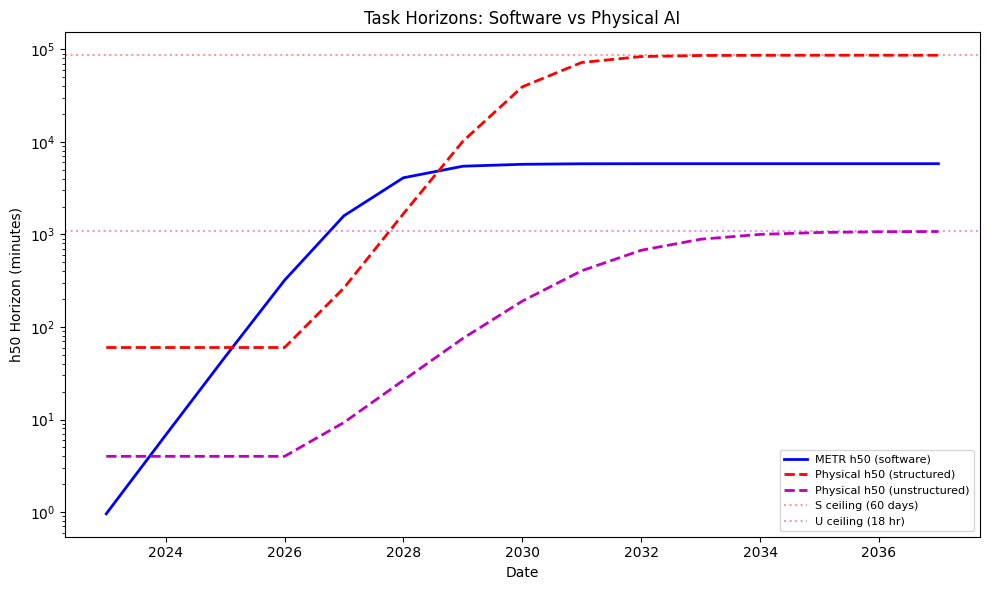

In [9]:
# Physical horizon projections alongside METR
fig, ax = plt.subplots(figsize=(10, 6))

# Base date for physical model is Jan 2026
phys_base = date(2026, 1, 1)
phys_t = [(d - phys_base).days / 30.44 for d in dates]

# METR h50 (from earlier fit)
ax.plot(dates, summary["h50_median"], "b-", linewidth=2, label="METR h50 (software)")

# Physical h50 by environment type, using median SW speedup
h50_structured = []
h50_unstructured = []
for d, t_p in zip(dates, phys_t):
    sw = sw_speedup_by_year.get(d, 1.0)
    t_phys = max(t_p, 0)
    h50_structured.append(ph.horizon_at(t_phys, "structured", sw))
    h50_unstructured.append(ph.horizon_at(t_phys, "unstructured", sw))

ax.plot(dates, h50_structured, "r--", linewidth=2, label="Physical h50 (structured)")
ax.plot(dates, h50_unstructured, "m--", linewidth=2, label="Physical h50 (unstructured)")

# Show ceilings
ax.axhline(
    y=ph.ceiling_structured, color="r", linestyle=":",
    alpha=0.4, label=f"S ceiling ({ph.ceiling_structured / 60 / 24:.0f} days)",
)
ax.axhline(
    y=ph.ceiling_unstructured, color="m", linestyle=":",
    alpha=0.4, label=f"U ceiling ({ph.ceiling_unstructured / 60:.0f} hr)",
)

ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("h50 Horizon (minutes)")
ax.set_title("Task Horizons: Software vs Physical AI")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

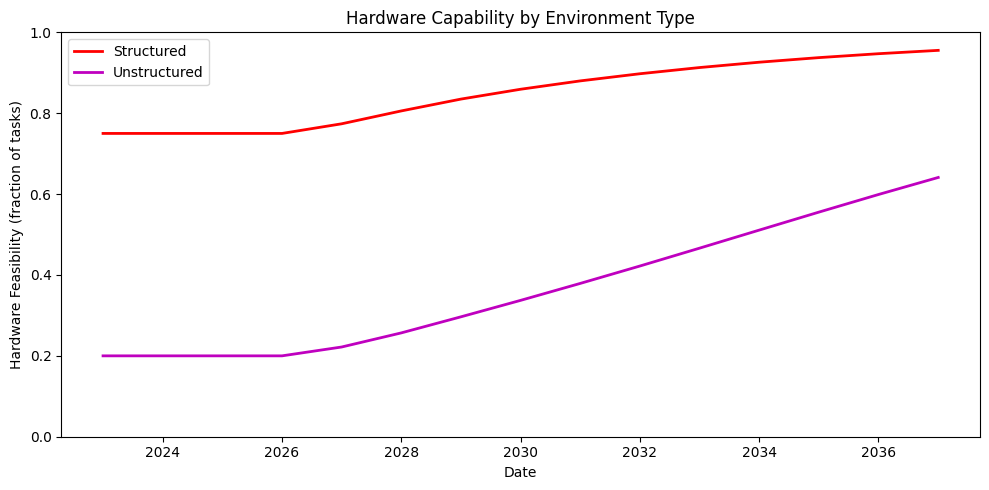

In [10]:
# Hardware capability evolution
fig, ax = plt.subplots(figsize=(10, 5))

hw_structured = []
hw_unstructured = []
for d, t_p in zip(dates, phys_t):
    sw = sw_speedup_by_year.get(d, 1.0)
    t_phys = max(t_p, 0)
    hw_structured.append(hw.feasibility_at(t_phys, "structured", sw))
    hw_unstructured.append(hw.feasibility_at(t_phys, "unstructured", sw))

ax.plot(dates, hw_structured, "r-", linewidth=2, label="Structured")
ax.plot(dates, hw_unstructured, "m-", linewidth=2, label="Unstructured")
ax.set_ylim(0, 1)
ax.set_xlabel("Date")
ax.set_ylabel("Hardware Feasibility (fraction of tasks)")
ax.set_title("Hardware Capability by Environment Type")
ax.legend()
plt.tight_layout()
plt.show()

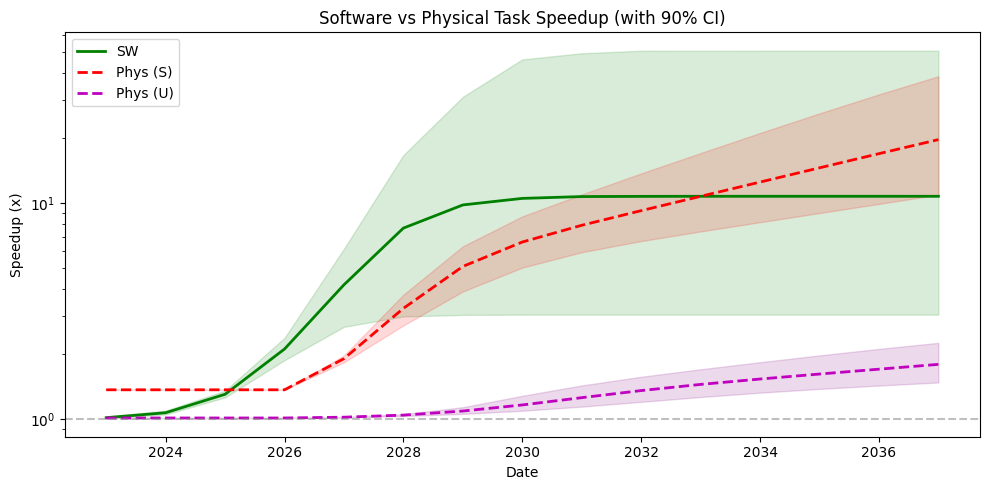

  Year          SW          Phys-S          Phys-U    HW-S    HW-U
  2023        1.01   1.36 [ 1.4-  1.4]   1.01 [ 1.0-  1.0]    0.75    0.20
  2024        1.07   1.36 [ 1.4-  1.4]   1.01 [ 1.0-  1.0]    0.75    0.20
  2025        1.30   1.36 [ 1.4-  1.4]   1.01 [ 1.0-  1.0]    0.75    0.20
  2026        2.11   1.36 [ 1.4-  1.4]   1.01 [ 1.0-  1.0]    0.75    0.20
  2027        4.18   1.90 [ 1.8-  2.0]   1.02 [ 1.0-  1.0]    0.77    0.22
  2028        7.66   3.25 [ 2.7-  3.8]   1.04 [ 1.0-  1.0]    0.81    0.26
  2029        9.81   5.09 [ 3.9-  6.3]   1.09 [ 1.1-  1.1]    0.83    0.30
  2030       10.52   6.60 [ 5.0-  8.7]   1.16 [ 1.1-  1.3]    0.86    0.34
  2031       10.73   7.89 [ 5.9- 11.0]   1.25 [ 1.1-  1.4]    0.88    0.38
  2032       10.75   9.23 [ 6.7- 13.7]   1.35 [ 1.2-  1.6]    0.90    0.42
  2033       10.76  10.75 [ 7.4- 17.1]   1.44 [ 1.3-  1.7]    0.91    0.47
  2034       10.76  12.52 [ 8.2- 21.2]   1.53 [ 1.3-  1.8]    0.93    0.51
  2035       10.76  14.58 [ 9.0- 

In [11]:
# Combined speedup with Monte Carlo: use SW speedup samples per year
phys_summary_rows = []
for d, t_p in zip(dates, phys_t):
    t_phys = max(t_p, 0)
    # Get SW speedup samples for this year from the results DataFrame
    sw_samples = results[results["date"] == d]["speedup"].values
    if len(sw_samples) == 0:
        sw_samples = np.array([1.0])

    for env, tasks in [("structured", phys_tasks_structured),
                       ("unstructured", phys_tasks_unstructured)]:
        ps = sample_physical_speedup(t_phys, sw_samples, env, tasks, ph, hw)
        phys_summary_rows.append({
            "date": d,
            "env": env,
            "median": np.median(ps),
            "p5": np.percentile(ps, 5),
            "p95": np.percentile(ps, 95),
        })

phys_summary = pd.DataFrame(phys_summary_rows)
ps_s = phys_summary[phys_summary["env"] == "structured"]
ps_u = phys_summary[phys_summary["env"] == "unstructured"]

fig, ax = plt.subplots(figsize=(10, 5))

# Software speedup
ax.plot(summary["date"], summary["speedup_median"], "g-", lw=2, label="SW")
ax.fill_between(
    summary["date"], summary["speedup_p5"], summary["speedup_p95"],
    alpha=0.15, color="green",
)

# Physical structured
ax.plot(ps_s["date"].values, ps_s["median"].values, "r--", lw=2, label="Phys (S)")
ax.fill_between(
    ps_s["date"].values, ps_s["p5"].values, ps_s["p95"].values,
    alpha=0.15, color="red",
)

# Physical unstructured
ax.plot(ps_u["date"].values, ps_u["median"].values, "m--", lw=2, label="Phys (U)")
ax.fill_between(
    ps_u["date"].values, ps_u["p5"].values, ps_u["p95"].values,
    alpha=0.15, color="purple",
)

ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Speedup (x)")
ax.set_title("Software vs Physical Task Speedup (with 90% CI)")
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# Summary table
print(
    f"{'Year':>6}  {'SW':>10}  {'Phys-S':>14}  {'Phys-U':>14}"
    f"  {'HW-S':>6}  {'HW-U':>6}"
)
for i, d in enumerate(dates):
    sw_med = summary[summary["date"] == d]["speedup_median"].values[0]
    s_row = ps_s[ps_s["date"] == d].iloc[0]
    u_row = ps_u[ps_u["date"] == d].iloc[0]
    hs = hw.feasibility_at(max(phys_t[i], 0), "structured", sw_med)
    hu = hw.feasibility_at(max(phys_t[i], 0), "unstructured", sw_med)
    print(
        f"{d.year:>6}  {sw_med:>10.2f}"
        f"  {s_row['median']:>5.2f}"
        f" [{s_row['p5']:>4.1f}-{s_row['p95']:>5.1f}]"
        f"  {u_row['median']:>5.2f}"
        f" [{u_row['p5']:>4.1f}-{u_row['p95']:>5.1f}]"
        f"  {hs:>6.2f}  {hu:>6.2f}"
    )